In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
df = pd.read_excel("Standby Diesel Generator.xlsx")
df.head()

,Month,load,class
0,4,40,no
1,6,50,no
2,7,80,no
3,10,100,no
4,12,120,no


In [5]:
X = df[["Month", "load"]]
y = df["class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5


In [6]:
for i in range(len(X_test)): 
    print("Test data:", X_test.iloc[i], "| True label:", y_test.iloc[i])
    if y_test.iloc[i] == y_pred[i]: 
        print("Correct prediction") 
    else: 
        print("Wrong prediction") 

Test data: Month     22
load     340
Name: 7, dtype: int64 | True label: yes
Wrong prediction
Test data: Month     6
load     50
Name: 1, dtype: int64 | True label: no
Correct prediction


In [8]:
H = float(input("Enter Month: "))
W = float(input("Enter Load: "))
predicted_label = knn.predict([[H, W]])
print("Predicted label:", predicted_label[0])

Enter Month:  5
Enter Load:  101


Predicted label: no


D:\hari anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


D:\hari anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


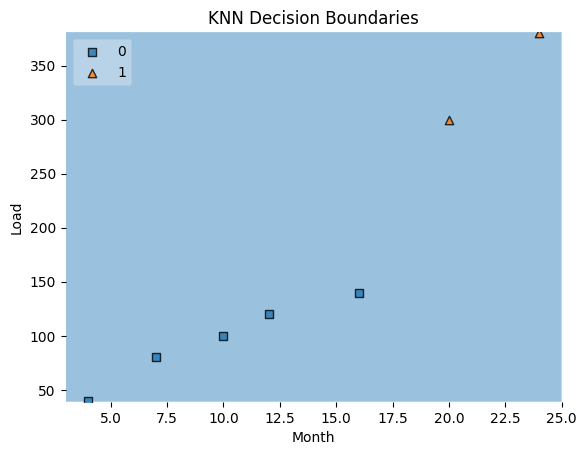

In [10]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)
knn.fit(X_train, y_train_int)
plot_decision_regions(X_train.values, y_train_int, clf=knn, legend=2)
plt.xlabel('Month')
plt.ylabel('Load')
plt.title('KNN Decision Boundaries')
plt.show()